In [15]:
import numpy as np
from scipy.stats import multivariate_t
from scipy.special import factorial
import lingam
import warnings
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from limvam.directlingam_extension import find_parent_variable, estimate_causal_order, directlingam_extension

# generate data

In [2]:
# parameters
m = 8
p = 6
n = 1000
random_state = 20
rng = np.random.RandomState(random_state)
disturbances = "gaussian"
n_runs = 100

In [3]:
def generate_data(
    m,
    p,
    n,
    rng=None,
    disturbances="gaussian",
):
    """
    Generate data according to the model xi = Bi xi + ei, where the Bi are DAG matrices 
    and the disturbances ei are correlated across views.
    """
    # variance of the disturbances
    M = rng.randn(p, m, m)
    Sigmas = np.zeros((p, m, m))
    for j in range(p):
        Sigmas[j] = M[j] @ M[j].T + m * np.eye(m)
    
    # disturbances
    E = np.zeros((m, p, n))
    for j in range(p):
        if disturbances == "gaussian":
            E[:, j] = rng.multivariate_normal(mean=np.zeros(m), cov=Sigmas[j], size=(n,)).T
        elif disturbances == "student_t":
            E[:, j] = multivariate_t.rvs(loc=np.zeros(m), shape=Sigmas[j], df=1, size=n, random_state=rng).T
        else:
            raise ValueError("The parameter 'disturbances' should be 'gaussian' or 'student_t'.")

    # strictly lower triangular matrices T
    T = rng.normal(size=(m, p, p))
    for i in range(m):
        T[i][np.triu_indices(p, k=0)] = 0
    
    # causal order P
    order = rng.permutation(p)
    P = np.eye(p)[order]

    # causal effect matrices B
    B = P.T @ T @ P
    
    # mixing matrices
    A = np.linalg.inv(np.eye(p) - B)
    
    # observations
    X = np.array([Ai @ Ei for Ai, Ei in zip(A, E)])
    return X, B, T, P, order

# Multiple runs of DirectLiNGAM extension

In [4]:
# percentage of runs where the parent variable --and then the entire ordering-- are found
success1 = 0
success2 = 0

for _ in range(n_runs):
    X, _, _, _, order = generate_data(m, p, n, rng, disturbances)
    # root variable
    estimated_first_vb, _ = find_parent_variable(X)
    success1 += (order[0] == estimated_first_vb)
    # entire ordering
    estimated_order = estimate_causal_order(X)
    success2 += (order == estimated_order).all()
    
success1 /= n_runs
success2 /= n_runs

In [5]:
print(f"Percentage of runs where the parent variable is found : {success1*100:.2f} %")
print(f"Chance level : {100/p:.2f} %\n")

print(f"Percentage of runs where the entire ordering is found : {success2*100:.2f} %")
print(f"Chance level : {100/factorial(p):.2f} %\n")

Percentage of runs where the parent variable is found : 100.00 %
Chance level : 16.67 %

Percentage of runs where the entire ordering is found : 100.00 %
Chance level : 0.14 %



# One run of DirectLiNGAM extension

In [6]:
# generate data
X, B, T, P, order = generate_data(m, p, n, rng, disturbances)

In [7]:
# run our extension of DirectLiNGAM
B_estimates, T_estimates, P_estimate = directlingam_extension(X)
order_estimate = np.argmax(P_estimate, axis=1)

In [9]:
print(f"True order : {order}")
print(f"Estimated order (ours) : {order_estimate}")

True order : [0 1 3 4 5 2]
Estimated order (ours) : [0 1 3 4 5 2]


# MultiGroupDirectLiNGAM

In [11]:
model = lingam.MultiGroupDirectLiNGAM()
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)
    model.fit(list(np.swapaxes(X, 1, 2)))
order_estimate_2 = model.causal_order_

In [12]:
print(f"True order : {order}")
print(f"Estimated order (not ours): {order_estimate_2}")

True order : [0 1 3 4 5 2]
Estimated order (not ours): [5, 0, 3, 2, 4, 1]


# plot

In [16]:
# matplotlib style
fontsize = 22
rc = {
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize,
}
plt.rcParams.update(rc)

In [17]:
# plot matrices
def plot_heat_maps(T, suptitle="", fontsize=22):
    m = len(T)
    fig, axes = plt.subplots(1, m, figsize=(m*5, 5))
    norm = TwoSlopeNorm(vmin=min(-1, np.min(T)), vmax=max(1, np.max(T)), vcenter=0)
    for i, ax in enumerate(axes.flat):
        im = ax.imshow(T[i], norm=norm, cmap="coolwarm")
        ax.set_title(f"View {i}", fontsize=fontsize)
    cbar = fig.colorbar(im, ax=axes, fraction=0.022, pad=0.03)
    cbar.set_label("Color Scale", fontsize=fontsize)
    fig.supxlabel("Variables", fontsize=fontsize)
    fig.supylabel("Variables", x=0.1, fontsize=fontsize)
    fig.suptitle(suptitle, fontsize=fontsize)
    plt.show()

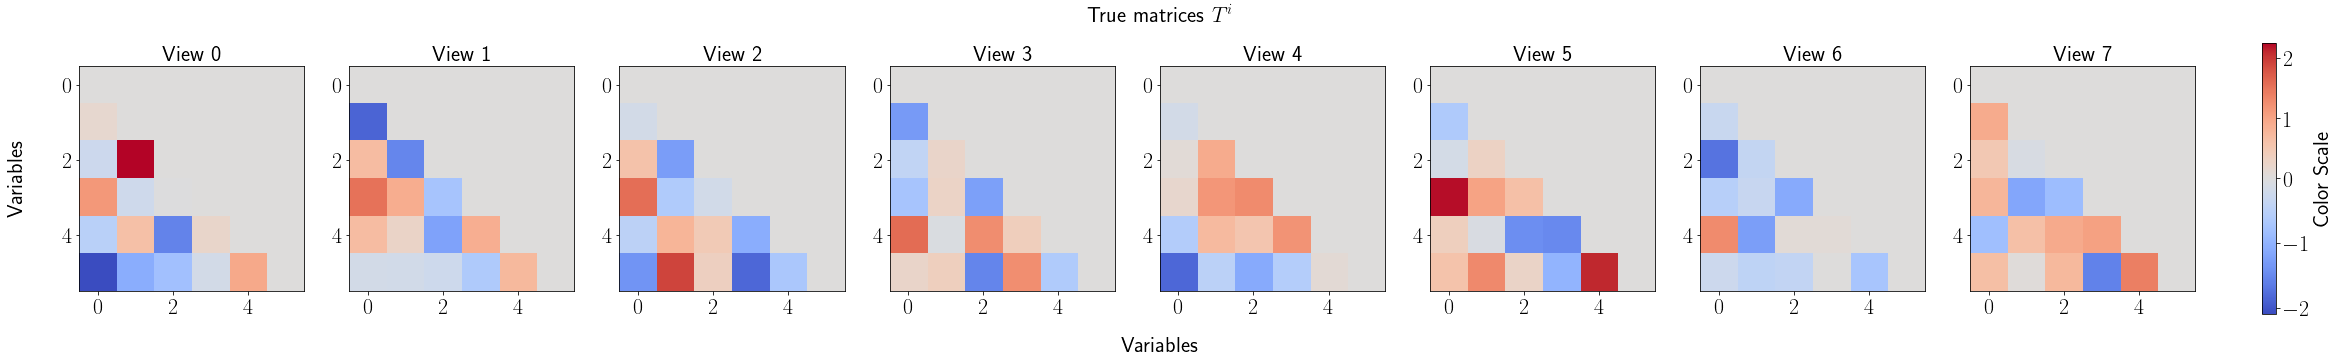

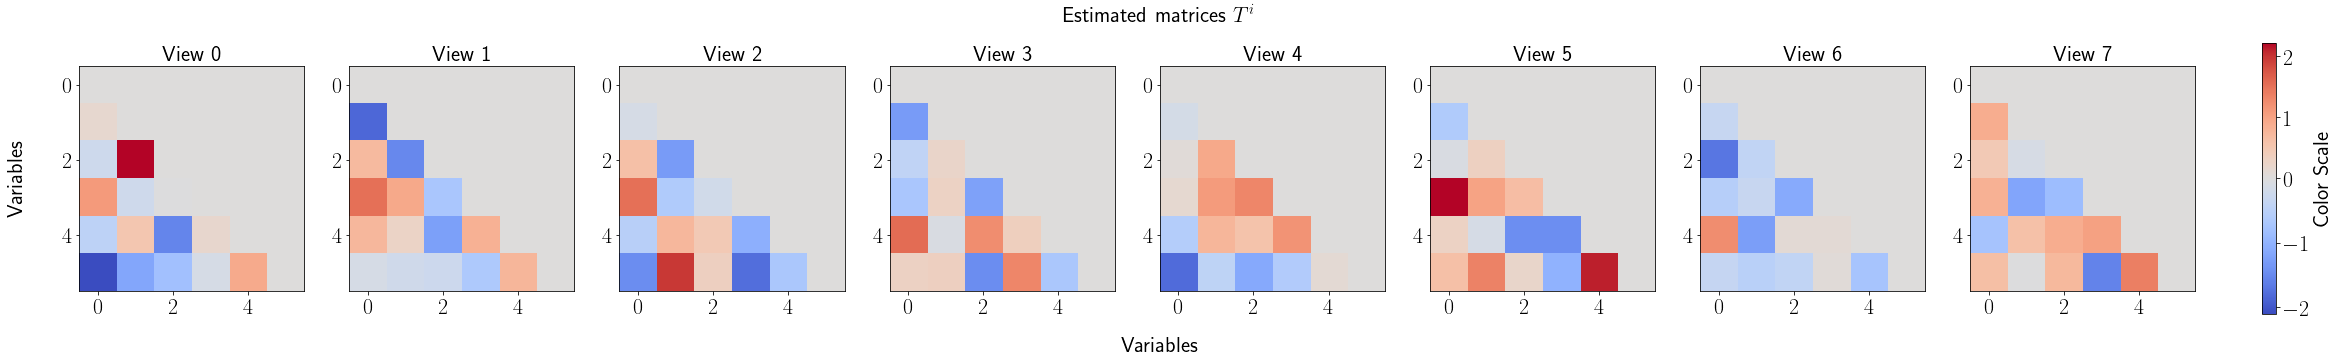

In [19]:
plot_heat_maps(T, suptitle=r"True matrices $T^i$")
plot_heat_maps(T_estimates, suptitle=r"Estimated matrices $T^i$")

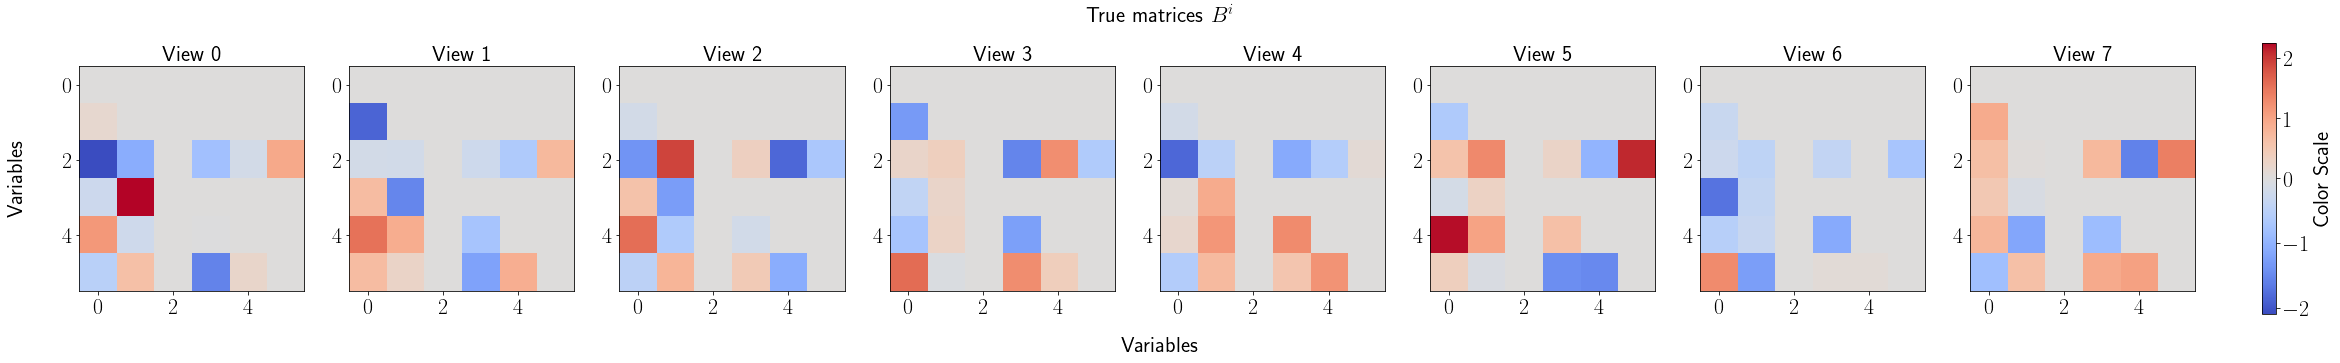

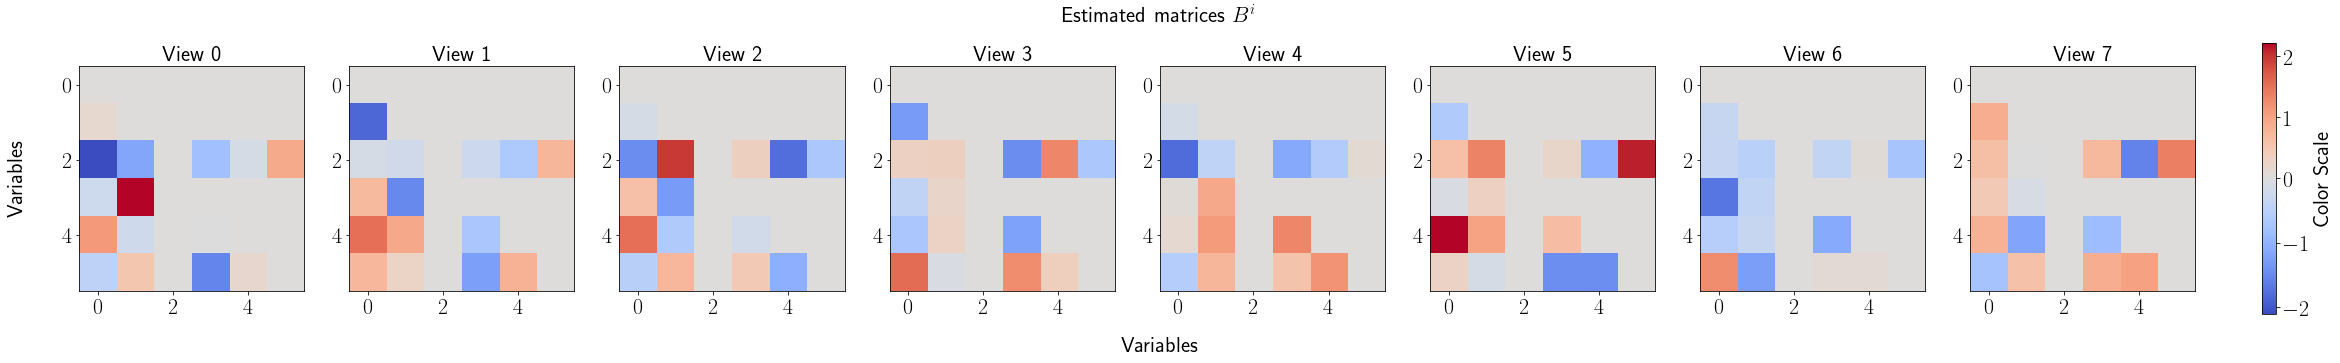

In [20]:
plot_heat_maps(B, suptitle=r"True matrices $B^i$")
plot_heat_maps(B_estimates, suptitle=r"Estimated matrices $B^i$")